# Notebook Base de Benchmarking entre Modelos

Este notebook compara **Kimi**, **Claude Opus**, **GPT-5.5** e **Gemini** usando os mesmos prompts e métricas padronizadas.

Métricas coletadas:
- Tokens de entrada e saída
- Tempo de resposta
- Custo estimado
- Qualidade da resposta (avaliação manual ou automatizada)

## 1. Configuração do ambiente

In [ ]:
# Instalação das dependências (execute uma vez)
# !pip install openai anthropic google-generativeai python-dotenv pandas matplotlib

In [2]:
import os
import time
import json
import pandas as pd
from dotenv import load_dotenv

# Clientes
import openai
import anthropic
import google.generativeai as genai

load_dotenv()

# Credenciais
KIMI_API_KEY = os.getenv("KIMI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Clientes configurados
kimi_client = openai.OpenAI(api_key=KIMI_API_KEY, base_url="https://api.moonshot.ai/v1")
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
genai.configure(api_key=GOOGLE_API_KEY)

## 2. Tabela de preços por 1M tokens

Atualize os valores conforme a tabela oficial de cada provider.

In [3]:
# Preços por 1M tokens (USD) — verificados em 2026-08-03.
# As chaves precisam bater com o campo "provider" retornado por cada call_*().
PRICES = {
    "kimi":        {"input":  3.00, "output": 15.00},  # kimi-k3 (Moonshot)
    "claude-opus": {"input":  5.00, "output": 25.00},  # claude-opus-5 (Anthropic)
    "gpt-5.5":     {"input":  5.00, "output": 30.00},  # gpt-5.5 (OpenAI), faixa <272K
    "gemini":      {"input":  1.50, "output":  7.50},  # gemini-3.6-flash (Google)
}

## 3. Função padronizada de chamada

Cada modelo recebe o mesmo `system_prompt` e `user_prompt`. A função retorna sempre a mesma estrutura de dados.

In [4]:
def call_kimi(system_prompt, user_prompt, model="kimi-k3"):
    start = time.time()
    response = kimi_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=1.0
    )
    elapsed = time.time() - start
    return {
        "provider": "kimi",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_claude(system_prompt, user_prompt, model="claude-opus-5"):
    start = time.time()
    # O claude-opus-5 não aceita temperature (400 invalid_request_error) e vem com
    # thinking ligado por padrão, que consome parte do max_tokens — por isso o
    # limite é mais folgado que os 4096 usados no opus-4-6.
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=16000,
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}]
    )
    elapsed = time.time() - start
    # Com thinking ligado, content[0] é um bloco 'thinking'; o texto vem depois.
    text = next(b.text for b in response.content if b.type == "text")
    return {
        "provider": "claude-opus",
        "model": model,
        "response": text,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.input_tokens + response.usage.output_tokens,
        "time_seconds": elapsed
    }

def call_openai(system_prompt, user_prompt, model="gpt-5.5"):
    start = time.time()
    # O gpt-5.5 aceita apenas o temperature padrão (1). Enviar 0.3 devolve
    # 400 unsupported_value, por isso o parâmetro é omitido aqui.
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    elapsed = time.time() - start
    return {
        "provider": "gpt-5.5",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_gemini(system_prompt, user_prompt, model="gemini-3.6-flash"):
    start = time.time()
    gemini_model = genai.GenerativeModel(model)
    response = gemini_model.generate_content(
        [system_prompt, user_prompt],
        generation_config={"temperature": 0.3}
    )
    elapsed = time.time() - start
    usage = response.usage_metadata
    # O preço de output do Gemini inclui os tokens de raciocínio, que NÃO entram
    # em candidates_token_count e não são expostos em campo próprio neste SDK.
    # (total - prompt) captura raciocínio + resposta, que é o que é cobrado.
    output_tokens = usage.total_token_count - usage.prompt_token_count
    return {
        "provider": "gemini",
        "model": model,
        "response": response.text,
        "input_tokens": usage.prompt_token_count,
        "output_tokens": output_tokens,
        "total_tokens": usage.total_token_count,
        "time_seconds": elapsed
    }

## 4. Função de cálculo de custo e execução do benchmark

In [5]:
def calculate_cost(provider, input_tokens, output_tokens):
    prices = PRICES.get(provider, {})
    input_cost = (input_tokens / 1_000_000) * prices.get("input", 0)
    output_cost = (output_tokens / 1_000_000) * prices.get("output", 0)
    return round(input_cost + output_cost, 6)

# Colunas usadas para exibir a tabela resumida (sem o texto completo da resposta)
SUMMARY_COLS = ["provider", "model", "input_tokens", "output_tokens",
                "total_tokens", "time_seconds", "cost_usd"]

def run_benchmark(system_prompt, user_prompt):
    results = []
    callers = [call_kimi, call_claude, call_openai, call_gemini]
    
    for caller in callers:
        try:
            result = caller(system_prompt, user_prompt)
            result["cost_usd"] = calculate_cost(
                result["provider"],
                result["input_tokens"],
                result["output_tokens"]
            )
            results.append(result)
        except Exception as e:
            results.append({
                "provider": caller.__name__.replace("call_", ""),
                "model": "error",
                "response": str(e),
                "input_tokens": 0,
                "output_tokens": 0,
                "total_tokens": 0,
                "time_seconds": 0,
                "cost_usd": 0
            })
    
    # Mantém a coluna 'response': as células seguintes exibem e avaliam o texto.
    # Use df[SUMMARY_COLS] quando quiser só as métricas.
    return pd.DataFrame(results)[SUMMARY_COLS + ["response"]]

def display_responses(df):
    for _, row in df.iterrows():
        print(f"\n=== {row['provider'].upper()} | {row['model']} ===")
        print(f"Tokens: {row['total_tokens']} | Tempo: {row['time_seconds']:.2f}s | Custo: ${row['cost_usd']:.6f}")
        print("-" * 60)

## 5. Benchmark textual

In [6]:
system_prompt = "Você é um especialista em tecnologia. Responda de forma clara e objetiva."
user_prompt = "Explique o que é um LLM e cite três aplicações práticas em desenvolvimento de software."

df_text = run_benchmark(system_prompt, user_prompt)
df_text[SUMMARY_COLS]

,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,kimi,kimi-k3,143,910,1053,28.733307,0.014079
1,claude-opus,claude-opus-5,67,1177,1244,18.639348,0.029760
2,gpt-5.5,gpt-5.5,44,252,296,7.263249,0.007780
3,gemini,gemini-3.6-flash,36,1211,1247,7.571356,0.009137


In [7]:
display_responses(df_text)

for _, row in df_text.iterrows():
    print(f"\n{row['provider'].upper()}:")
    print(row['response'][:500] + "..." if len(row['response']) > 500 else row['response'])


=== KIMI | kimi-k3 ===
Tokens: 1053 | Tempo: 28.73s | Custo: $0.014079
------------------------------------------------------------

=== CLAUDE-OPUS | claude-opus-5 ===
Tokens: 1244 | Tempo: 18.64s | Custo: $0.029760
------------------------------------------------------------

=== GPT-5.5 | gpt-5.5 ===
Tokens: 296 | Tempo: 7.26s | Custo: $0.007780
------------------------------------------------------------

=== GEMINI | gemini-3.6-flash ===
Tokens: 1247 | Tempo: 7.57s | Custo: $0.009137
------------------------------------------------------------

KIMI:
## O que é um LLM

**LLM (Large Language Model**, ou Modelo de Linguagem de Grande Escala) é um tipo de modelo de inteligência artificial baseado em redes neurais profundas, geralmente na arquitetura **Transformer**. Ele é treinado com volumes massivos de texto (livros, sites, código-fonte, documentação) para aprender padrões estatísticos da linguagem.

Na prática, um LLM funciona prevendo o próximo token (palavra ou fragmento) mais 

## 6. Benchmark de geração de código

In [8]:
system_code = "Você é um desenvolvedor Python sênior. Retorne apenas o código, sem explicações."
user_code = """Escreva uma função Python chamada `is_prime(n)` que verifica se um número inteiro é primo.
Inclua também 3 testes unitários usando assert."""

df_code = run_benchmark(system_code, user_code)
df_code[SUMMARY_COLS]

,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,kimi,kimi-k3,158,398,556,13.812604,0.006444
1,claude-opus,claude-opus-5,95,288,383,5.632454,0.007675
2,gpt-5.5,gpt-5.5,62,164,226,7.601331,0.005230
3,gemini,gemini-3.6-flash,55,737,792,4.020924,0.005610


In [9]:
import re

def extract_python_code(response):
    """Extrai blocos de código markdown da resposta."""
    match = re.search(r"```python\n(.*?)\n```", response, re.DOTALL)
    return match.group(1) if match else response

def evaluate_code(response):
    """Tenta executar o código gerado e verifica se passa nos asserts."""
    code = extract_python_code(response)
    try:
        exec(code, {})
        return "OK"
    except AssertionError:
        return "ASSERT_FAILED"
    except Exception as e:
        return f"ERROR: {e}"

df_code["execution_result"] = df_code["response"].apply(evaluate_code)
df_code[["provider", "cost_usd", "execution_result"]]

,provider,cost_usd,execution_result
0,kimi,0.006444,OK
1,claude-opus,0.007675,OK
2,gpt-5.5,0.005230,OK
3,gemini,0.005610,OK


## 7. Visualização comparativa

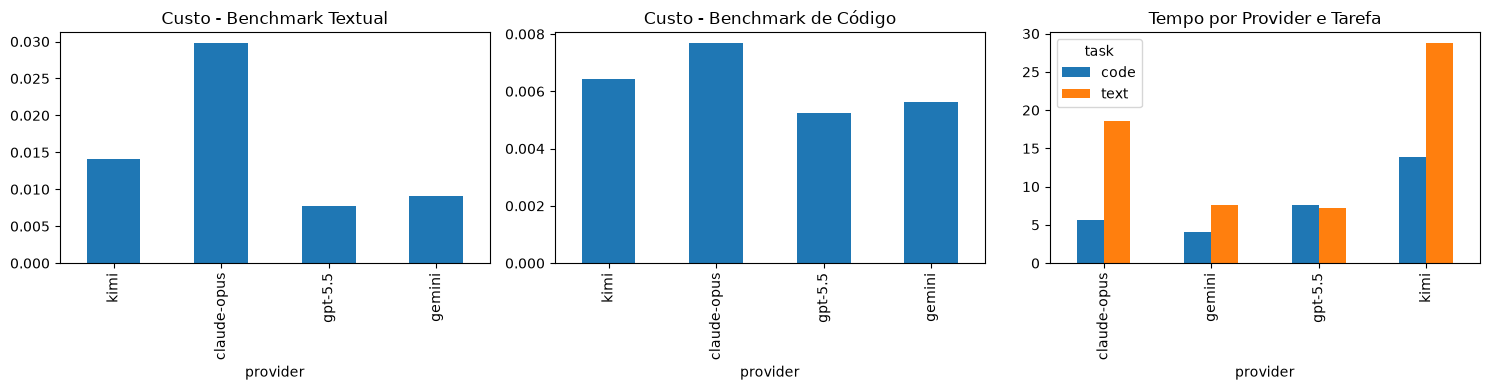

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_text.plot.bar(x="provider", y="cost_usd", ax=axes[0], title="Custo - Benchmark Textual", legend=False)
df_code.plot.bar(x="provider", y="cost_usd", ax=axes[1], title="Custo - Benchmark de Código", legend=False)

combined = pd.concat([
    df_text.assign(task="text"),
    df_code.assign(task="code")
])
combined.pivot(index="provider", columns="task", values="time_seconds").plot.bar(ax=axes[2], title="Tempo por Provider e Tarefa")

plt.tight_layout()
plt.show()

## 8. Exportação dos resultados

In [11]:
# Salva os resultados em CSV para análise posterior
df_text.to_csv("benchmark_texto.csv", index=False)
df_code.to_csv("benchmark_codigo.csv", index=False)
print("Resultados salvos em CSV")

Resultados salvos em CSV


## 9. Arquivo `.env` de exemplo

Crie um arquivo `.env` na mesma pasta do notebook com:

```
KIMI_API_KEY=sk-xxxxx
ANTHROPIC_API_KEY=sk-ant-xxxxx
OPENAI_API_KEY=sk-xxxxx
GOOGLE_API_KEY=xxxxx
```